# Programación Evolutiva

- Autor: <span style="color:red">Rodrigo S. Cortez-Madrigal</span>
- web: [https://roicort.github.io](https://roicort.github.io)
- github: [https://github.com/roicort/MetaZoo](https://github.com/roicort/MetaZoo)
- docs: [https://roicort.github.io/MetaZoo/](https://roicort.github.io/MetaZoo/)

In [5]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from metazoo.bio.darwin import ParticleSwarmOptimizer
from metazoo.bio.evolutionary import DifferentialEvolution
from metazoo.bio.evolutionary import GeneticAlgorithm
from metazoo.bio.evolutionary.operators import crossover, mutation, selection
from metazoo.gym.mono import Function
from metazoo.gym.combinatorial import TSP
from metazoo.bio.utils import encoding

import plotly.io as pio
#pio.renderers.default = "jupyterlab"
pio.renderers.default = "svg"

## Parametricos

In [6]:
targets = ['Sphere', 'Bukin', 'Himmelblau', 'EggHolder', 'Easom']

In [15]:
fitness_function = Function(targets[0], reverse=False)
encoder = encoding.Real(bounds=[(-5.12, 5.12), (-5.12, 5.12), (-5.12, 5.12), (-5.12, 5.12), (-5.12, 5.12)])

pso = ParticleSwarmOptimizer(
    fitness_function,
    encoder=encoder,
    population_size=40,
    inertia=0.7,
    cognitive=1.5,
    social=1.5,
    minimize=True,
)

de = DifferentialEvolution(
    fitness_function,
    encoder=encoder,
    population_size=40,
    F=0.8,
    CR=0.9,
    minimize=True,
)

ga = GeneticAlgorithm(
    fitness_function,
    encoder=encoder,
    crossover_function=crossover.onepoint,
    mutation_function=mutation.gaussian,
    selection_function=selection.tournament,
    population_size=40,
    crossover_rate=0.9,
    mutation_rate=0.1,
    minimize=True,
)

pso.run(iterations=100)
de.run(generations=100)
ga.run(generations=100)

print(f'Best Individual PSO: {pso.global_best_position}')
print(f'Best Fitness PSO: {pso.best_fitness}')

print(f'Best Individual DE: {de.best_individual}')
print(f'Best Fitness DE: {de.best_fitness}')

print(f'Best Individual GA: {ga.best_individual}')
print(f'Best Fitness GA: {ga.best_fitness}')

Output()

Output()

Best Individual PSO: [-2.7842932  -1.30844331 -2.82832906  5.12        0.26829136]
Best Fitness PSO: 10.230235020977982
Best Individual DE: [ 0.00560155 -0.00020955 -0.00575259  0.00300701  0.00423433]
Best Fitness DE: 9.148517161886025e-05
Best Individual GA: [0.         0.         0.         0.12885867 0.        ]
Best Fitness GA: 0.016604557096153657


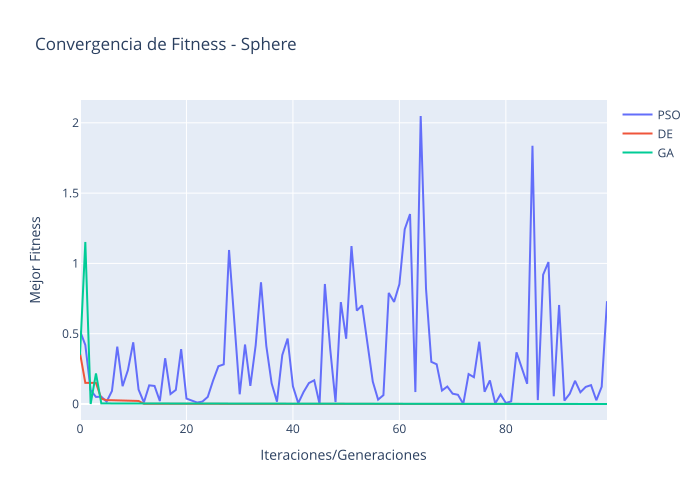

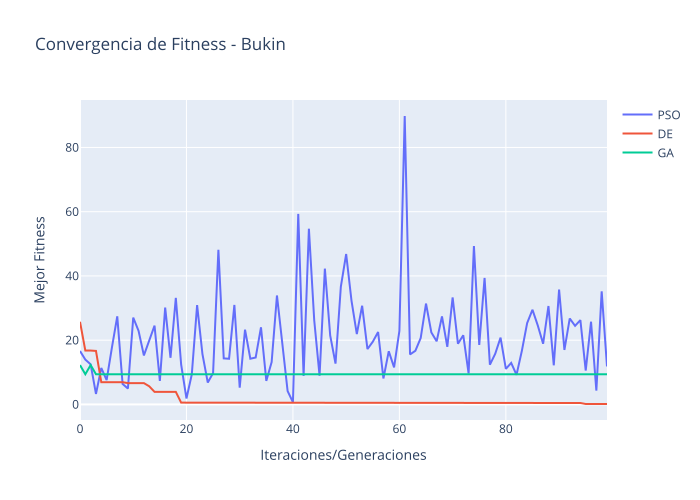

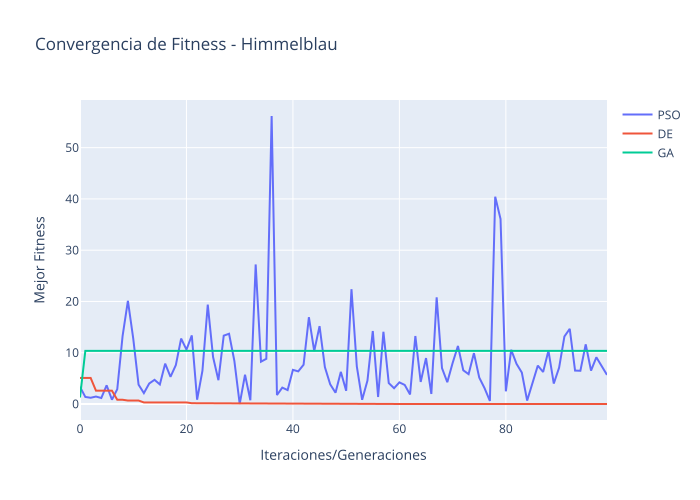

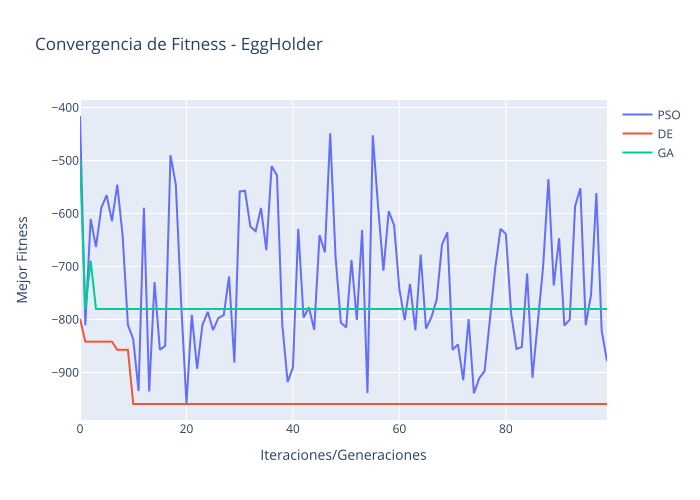

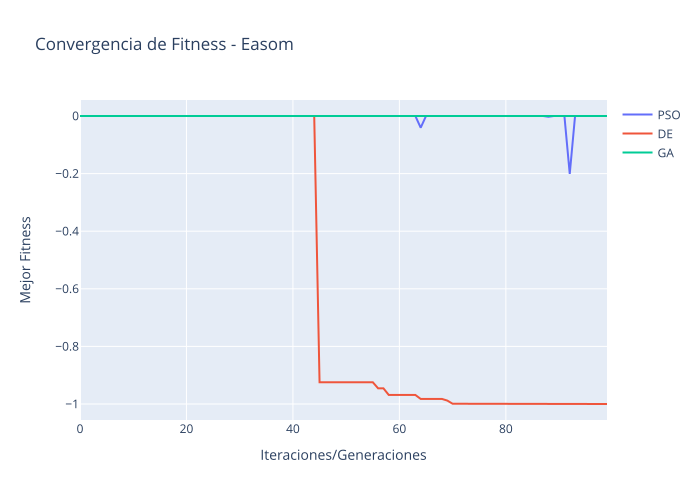

                           Resultados de Algoritmos Evolutivos                           
┏━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Función    ┃ Algoritmo ┃ Mejor Individuo                 ┃ Mejor Fitness ┃ Tiempo (s) ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ Sphere     │ PSO       │ [ 2.05898592 -0.74056231]       │ 0.7313        │ 0.0467     │
│ Sphere     │ DE        │ [5.42728732e-09 1.65084358e-09] │ 3.218e-17     │ 0.0770     │
│ Sphere     │ GA        │ [0. 0.]                         │ 0             │ 0.0443     │
│ Bukin      │ PSO       │ [-9.79479782 -3.        ]       │ 11.83         │ 0.0278     │
│ Bukin      │ DE        │ [-11.5789122    1.34071337]     │ 0.1293        │ 0.0849     │
│ Bukin      │ GA        │ [-5.63146252  0.32587721]       │ 9.394         │ 0.0404     │
│ Himmelblau │ PSO       │ [-4.26387393  3.24686276]       │ 5.679         │ 0.0233     │
│ Himmelblau │ DE        │ [ 3.58453575 -1.84816544]       │ 5.976e-07     │ 0.0826     │
│ Himmelblau │ GA        │ [2.38331201 2.1062331 ]         │ 10.36         │ 0.0355     │
│ EggHolder  │ PSO       │ [512.         100.33103739]     │ -878.8        │ 0.0324     │
│ EggHolder  │ DE        │ [512.         404.35921382]     │ -959.6        │ 0.0842     │
│ EggHolder  │ GA        │ [457.95866064 460.79354217]     │ -780.3        │ 0.0430     │
│ Easom      │ PSO       │ [-13.28801453  30.5208579 ]     │ -2.926e-09    │ 0.0260     │
│ Easom      │ DE        │ [3.14146263 3.14163098]         │ -1            │ 0.0799     │
│ Easom      │ GA        │ [0.19847188 1.        ]         │ -9.34e-07     │ 0.0472     │
└────────────┴───────────┴─────────────────────────────────┴───────────────┴────────────┘

In [19]:
from rich.console import Console
from rich.table import Table
import time

console = Console()

table = Table(title="Resultados de Algoritmos Evolutivos")
table.add_column("Función", style="bold cyan")
table.add_column("Algoritmo", style="bold magenta")
table.add_column("Mejor Individuo", style="white")
table.add_column("Mejor Fitness", style="green")
table.add_column("Tiempo (s)", style="yellow")

for target in targets:
    fitness_function = Function(target, reverse=False)
    encoder = encoding.Real(bounds=fitness_function.bounds)

    # PSO
    pso = ParticleSwarmOptimizer(
        fitness_function,
        encoder=encoder,
        population_size=40,
        inertia=0.7,
        cognitive=1.5,
        social=1.5,
        minimize=True,
    )
    start = time.time()
    pso.run(iterations=100, verbose=False)
    pso_time = time.time() - start

    # DE
    de = DifferentialEvolution(
        fitness_function,
        encoder=encoder,
        population_size=40,
        F=0.8,
        CR=0.9,
        minimize=True,
    )
    start = time.time()
    de.run(generations=100, verbose=False)
    de_time = time.time() - start

    # GA
    ga = GeneticAlgorithm(
        fitness_function,
        encoder=encoder,
        crossover_function=crossover.onepoint,
        mutation_function=mutation.gaussian,
        selection_function=selection.tournament,
        population_size=40,
        crossover_rate=0.9,
        mutation_rate=0.1,
        minimize=True,
    )
    start = time.time()
    ga.run(generations=100, verbose=False)
    ga_time = time.time() - start

    # Agrega resultados a la tabla
    table.add_row(target, "PSO", str(pso.global_best_position), f"{pso.best_fitness:.4g}", f"{pso_time:.4f}")
    table.add_row(target, "DE", str(de.best_individual), f"{de.best_fitness:.4g}", f"{de_time:.4f}")
    table.add_row(target, "GA", str(ga.best_individual), f"{ga.best_fitness:.4g}", f"{ga_time:.4f}")

    # Plot fitness convergence
    fig = go.Figure()
    fig.add_trace(go.Scatter(y=pso.best_history, mode='lines', name='PSO'))
    fig.add_trace(go.Scatter(y=de.best_history, mode='lines', name='DE'))
    fig.add_trace(go.Scatter(y=ga.best_history, mode='lines', name='GA'))
    fig.update_layout(title=f'Convergencia de Fitness - {target}',
                      xaxis_title='Iteraciones/Generaciones',
                      yaxis_title='Mejor Fitness')
    fig.show()

console.print(table)

## Combinatorios

In [12]:
tsp = TSP.Berlin52()
encoder = encoding.Permutation(permutation_size=tsp.dimension)

In [13]:
pso = ParticleSwarmOptimizer(
    tsp,
    encoder=encoder,
    population_size=200,
    inertia=0.7,
    cognitive=1.0,
    social=1.5,
    minimize=True,
)

pso.run(iterations=300)

print(f'Best Individual: {pso.best_individual.position}')
print(f'Best Fitness: {pso.best_fitness}')
print(f'Optimal Value: {tsp.optimal_value}')
print(f'Difference from Optimal: {pso.best_fitness - tsp.optimal_value}')

Output()

Best Individual: [28 36 10 12 27 18 25 11 50 26 15 35 14  5 43 39 40 24 46 22 20 45 32 51
 13 17  0 30 37 23 29 33 19  2 48 47 31  1  6 41 49 21  4  7 42  3 34 44
 16  8  9 38]
Best Fitness: 21722.085783140865
Optimal Value: 7542.0
Difference from Optimal: 14180.085783140865


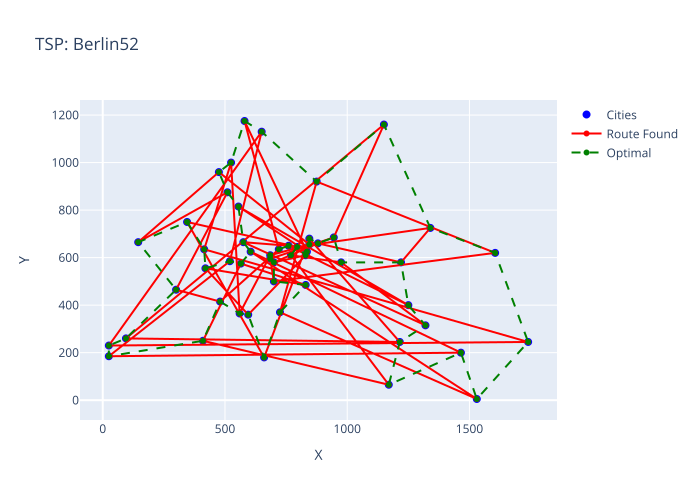

In [8]:
tsp.plot(show_optimal=True, solution=
         pso.global_best_position)

Output()

N-Queens: 8x8


****************************************
Permutation
Best Individual: [1 5 2 7 0 3 6 4]
Best Fitness: 5758.642561264716


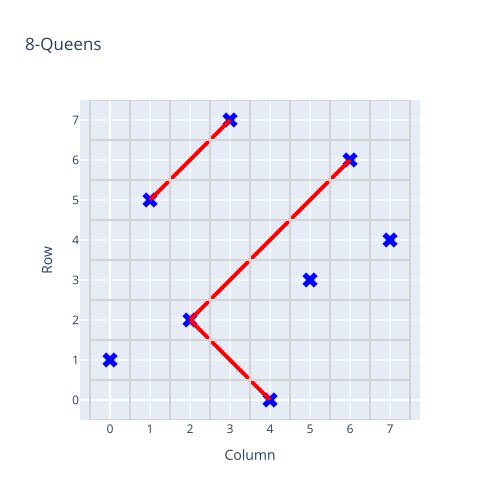

Output()

N-Queens: 12x12


****************************************
Permutation
Best Individual: [11  0  5  2  1  7 10  9  8  6  4  3]
Best Fitness: 10291.763472080094


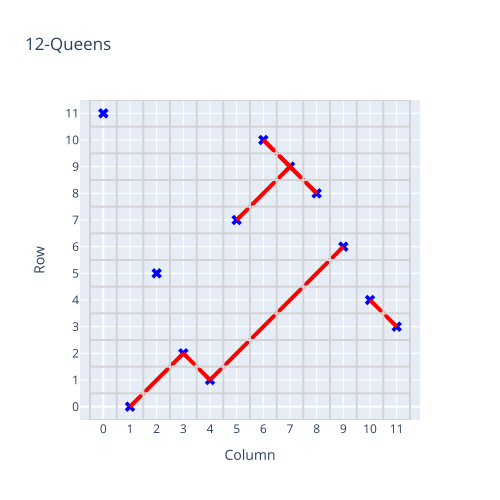

Output()

N-Queens: 24x24


****************************************
Permutation
Best Individual: [21 14 10  3 11 18 22 15  1  8 17 16  4 20 13  2  6 19  9  5 23  0 12  7]
Best Fitness: 18773.281642130634


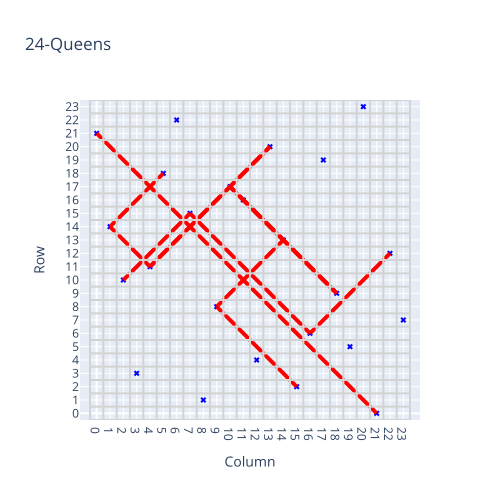

Output()

N-Queens: 48x48


****************************************
Permutation
Best Individual: [24 10 20 16 44 36 25 19  5 30 39 29 37 14  6 45 40 43 42 15 33  2  4 11
 21 26 46  3 27  0  7  1 35  8 23  9 13 12 34 32 38 17 22 47 18 28 31 41]
Best Fitness: 32575.16617993622


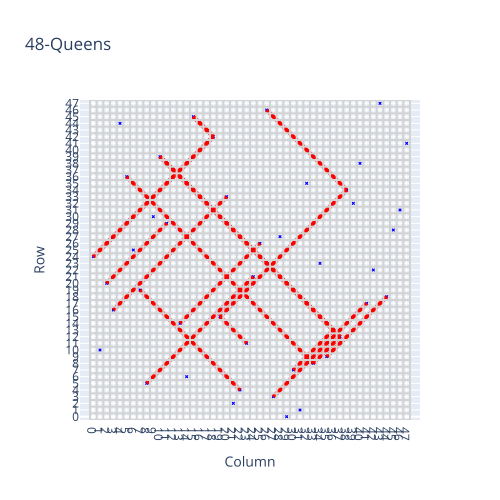

In [20]:
from metazoo.gym.combinatorial import NQueens


for N in [8, 12, 24, 48]:
    print(f"N-Queens: {N}x{N}")
    nqueens = NQueens(n=N)
    history = {}
    best_solutions = {}

    encoder = encoding.Permutation(permutation_size=N)

    pso = ParticleSwarmOptimizer(
        tsp,
        encoder=encoder,
        population_size=500,
        inertia=0.7,
        cognitive=1.5,
        social=1.5,
        minimize=False,
    )

    pso.run(iterations=500)

    print("*" * 40)
    print(type(encoder).__name__)
    print(f'Best Individual: {pso.best_individual.position}')
    print(f'Best Fitness: {pso.best_fitness}')
    nfig = nqueens.plot(solution=pso.best_individual.position, attacks=nqueens.attacks(pso.best_individual.position))
    nfig.show()